# Predicting the Commercial Success of Movies
### DSC 148 Final Project

**Research question.** *Using only information available **before a movie is released**
(budget, runtime, genre, director, language, release timing, cast size), can we predict
its commercial success? And does what drives **revenue** differ from what drives
**profitability (ROI)**?*

We attack this from three angles:

1. **Hypothesis testing** — are release timing, genre, and critical rating *significantly*
   associated with revenue?
2. **Supervised learning** — predict `log(revenue)` (regression) and whether a film is a
   *hit* i.e. ROI ≥ 1 (classification), benchmarking a ladder of models from a naïve
   baseline up to regularized linear models and tree ensembles.
3. **Unsupervised learning** — do natural movie *archetypes* exist (PCA + k-means + GMM)?

All predictive features are **pre-release** to avoid leakage (we deliberately exclude
`vote_count`, `popularity`, and `revenue` itself from the feature set).

In [46]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, silhouette_score)

sns.set_theme(style='whitegrid')
RNG = 42

## 1. Load the data and select a usable sample

The raw dataset has ~438K movies, but the vast majority are missing real financial
figures. A movie with `budget = 0` or `revenue = 0` is uninformative for a study of
commercial success, so our **first and most important modeling decision** is to keep only
films with genuine budget *and* revenue. This drops us to ~10K rows — a clean, well-defined
population of "real" theatrical releases.

In [47]:
df = pd.read_csv('dataset.csv')
print('raw rows:', len(df))

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df['runtime'] = df['runtime'].replace(0, np.nan).clip(upper=300)   # cap unrealistic runtimes
df = df.dropna(subset=['runtime'])
df = df[df['adult'] == False]
print('usable rows:', len(df))

raw rows: 438405
usable rows: 10088


Summary stats table by decade

In [48]:
df['roi'] = (df['revenue'] - df['budget']) / df['budget'] * 100
df['log_revenue'] = np.log1p(df['revenue'])
df['log_roi'] = np.log(df['roi'])
df['hit'] = (df['roi'] >= 0).astype(int)

print('hit class balance:')
print(df['hit'].value_counts(normalize=True).round(3))

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df = df[df['release_date'].dt.year <= 2024]
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

decade_stats = (
    df.groupby('decade')
    .agg(
        n         = ('revenue',      'size'),
        med_budget= ('budget',        'median'),
        med_rev   = ('revenue',       'median'),
        med_roi   = ('roi',           'median'),
        hit_rate  = ('hit',           'mean'),
    )
    .query("n >= 30")
    .round({'med_budget': 0, 'med_rev': 0, 'med_roi': 2, 'hit_rate': 3})
)

fmt = lambda x: f"${x:,.0f}"
display(
    decade_stats.assign(
        med_budget = decade_stats['med_budget'].apply(fmt),
        med_rev    = decade_stats['med_rev'].apply(fmt),
    ).rename(columns={
        'n':         'Films',
        'med_budget':'Median Budget',
        'med_rev':   'Median Revenue',
        'med_roi':   'Median ROI (×)',
        'hit_rate':  'Hit Rate',
    })
)

hit class balance:
hit
1    0.672
0    0.328
Name: proportion, dtype: float64


,Films,Median Budget,Median Revenue,Median ROI (×),Hit Rate
decade,,,,,
1920s,52,"$385,000","$1,261,500",251.46,0.923
1930s,117,"$628,000","$1,700,000",142.99,0.957
1940s,153,"$1,318,000","$2,750,000",132.70,0.902
1950s,194,"$1,430,500","$3,600,000",159.36,0.887
1960s,224,"$2,500,000","$7,950,000",190.77,0.821
1970s,334,"$2,950,000","$15,734,661",403.03,0.865
1980s,853,"$9,000,000","$16,116,878",111.42,0.699
1990s,1422,"$17,255,000","$18,549,640",45.30,0.617
2000s,2685,"$15,000,000","$18,024,545",51.00,0.633


Summary stats by top genre

In [49]:
df['primary_genre'] = df['genres'].fillna('Unknown').str.split(', ').str[0]

genre_stats = (
    df.groupby('primary_genre')
    .agg(n=('revenue','size'), med_rev=('revenue','median'), med_roi=('roi','median'), hit_rate=('hit','mean'))
    .query("n >= 50")
    .sort_values('med_rev', ascending=False)
    .round({'med_rev': 0, 'med_roi': 2, 'hit_rate': 3})
)
display(
    genre_stats.assign(med_rev=genre_stats['med_rev'].apply(lambda x: f"${x:,.0f}"))
    .rename(columns={'n':'Films','med_rev':'Median Revenue','med_roi':'Median ROI (×)','hit_rate':'Hit Rate'})
)

,Films,Median Revenue,Median ROI (×),Hit Rate
primary_genre,,,,
Fantasy,214,"$46,657,413",101.77,0.752
Family,201,"$42,365,581",91.73,0.761
Adventure,566,"$38,911,488",93.41,0.701
Science Fiction,228,"$32,372,336",69.39,0.689
Animation,324,"$31,089,413",79.68,0.725
Action,1461,"$22,896,728",80.00,0.689
Horror,664,"$14,297,553",153.66,0.747
Comedy,2152,"$13,000,000",100.00,0.698
Mystery,127,"$11,511,031",45.99,0.575


Films-per-year time series

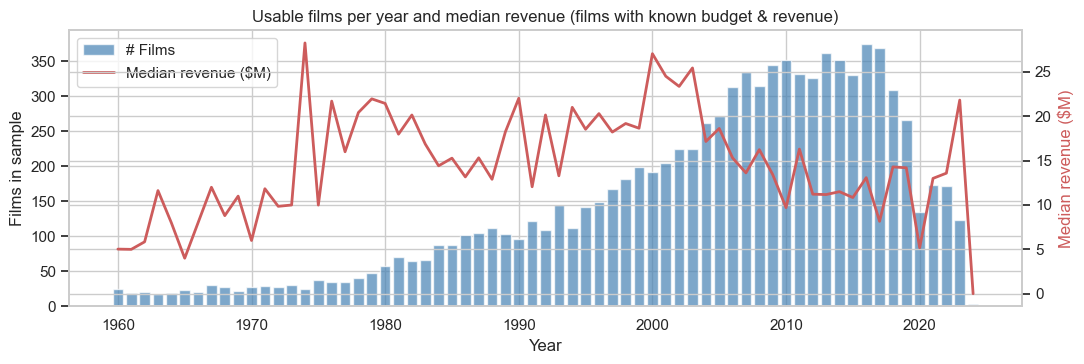

In [50]:
yearly = df.groupby('release_year').agg(n=('revenue','size'), med_rev=('revenue','median'))
yearly = yearly[yearly.index >= 1960]

fig, ax1 = plt.subplots(figsize=(11, 3.8))
ax1.bar(yearly.index, yearly['n'], color='steelblue', alpha=0.7, label='# Films')
ax1.set_ylabel('Films in sample'); ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['med_rev'] / 1e6, color='indianred', lw=2, label='Median revenue ($M)')
ax2.set_ylabel('Median revenue ($M)', color='indianred')

ax1.set_title('Usable films per year and median revenue (films with known budget & revenue)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout(); plt.show()

Genre-level revenue bar chart

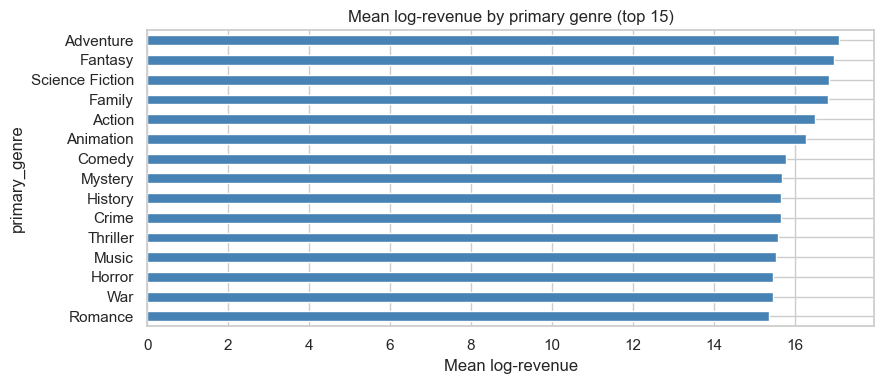

In [51]:
genre_rev = (
    df.groupby('primary_genre')['log_revenue'].mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 4))
genre_rev.iloc[::-1].plot(kind='barh', color='steelblue')
plt.xlabel('Mean log-revenue'); plt.title('Mean log-revenue by primary genre (top 15)')
plt.tight_layout(); plt.show()

Correlation heatmap of numeric features

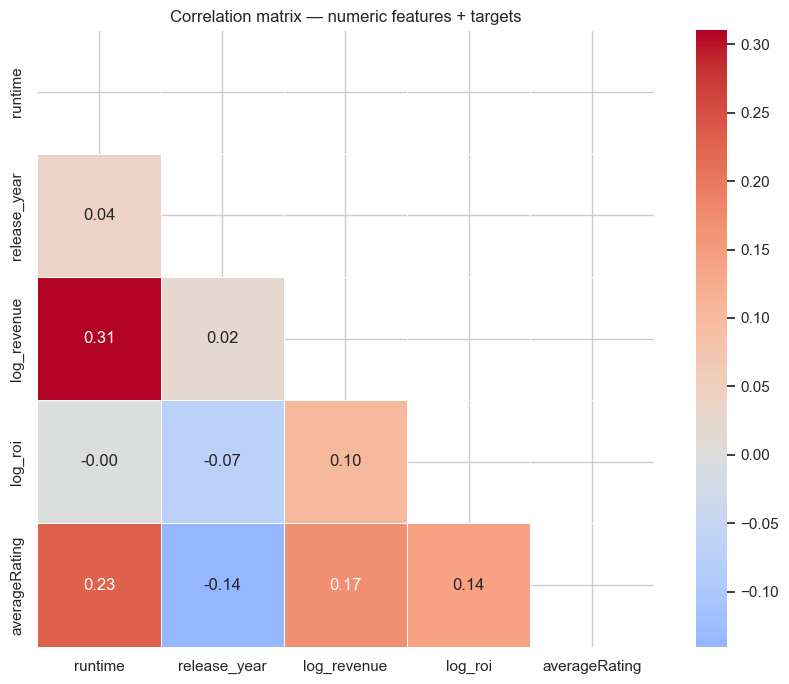

In [52]:
corr_cols = ['log_budget', 'runtime', 'release_year', 'cast_size',
             'n_genres', 'n_prod_countries', 'n_spoken_langs',
             'log_revenue', 'log_roi', 'averageRating']

corr_cols_present = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols_present].corr().round(2)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation matrix — numeric features + targets')
plt.tight_layout(); plt.show()

## 2. Define the targets

- **`log_revenue`** — regression target. Revenue spans many orders of magnitude and is
  heavily right-skewed, so we model its log (this linearises the budget→revenue relationship
  and stabilises the error variance).
- **`roi = revenue / budget`** and **`log_roi`** — a *profitability* target that controls
  for how much was spent.
- **`hit`** — classification target: `1` if the film at least broke even (ROI ≥ 1).

In [53]:
df['roi'] = (df['revenue'] - df['budget']) / df['budget'] * 100
df['log_revenue'] = np.log1p(df['revenue'])
df['log_roi'] = np.log(df['roi'])
df['hit'] = (df['roi'] >= 0).astype(int)

print('hit class balance:')
print(df['hit'].value_counts(normalize=True).round(3))

hit class balance:
hit
1    0.671
0    0.329
Name: proportion, dtype: float64


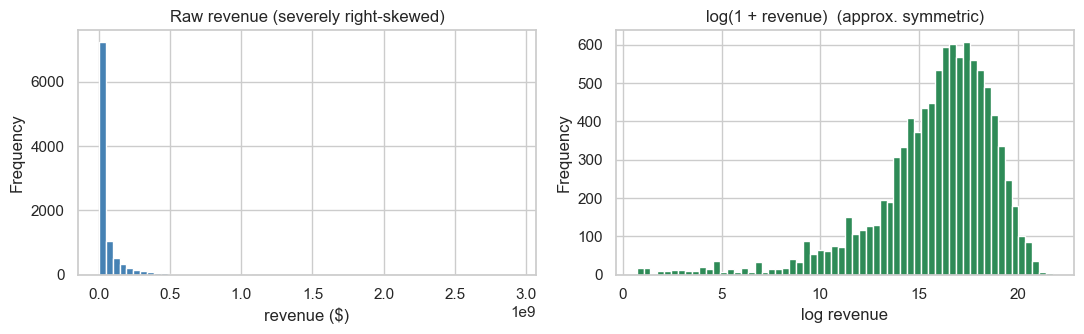

In [54]:
# Show WHY we log-transform: raw vs log revenue
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df['revenue'].plot(kind='hist', bins=60, ax=ax[0], color='steelblue')
ax[0].set_title('Raw revenue (severely right-skewed)'); ax[0].set_xlabel('revenue ($)')
df['log_revenue'].plot(kind='hist', bins=60, ax=ax[1], color='seagreen')
ax[1].set_title('log(1 + revenue)  (approx. symmetric)'); ax[1].set_xlabel('log revenue')
plt.tight_layout(); plt.show()

## 3. Feature engineering — pre-release features only

Every feature below is knowable *before* a movie opens. We deliberately leave out
post-release popularity signals to keep this an honest forecasting problem.

- **Numeric / engineered:** `log_budget`, `runtime`, `release_year`, `release_month`,
  `summer`, `holiday`, `cast_size`, `n_prod_countries`, `n_spoken_langs`, `n_genres`
- **One-hot:** genres, top-30 directors (+ "Other"), top-10 original languages (+ "Other")

In [55]:

df['summer']  = df['release_month'].isin([5, 6, 7]).astype(int)
df['holiday'] = df['release_month'].isin([11, 12]).astype(int)

df['log_budget'] = np.log1p(df['budget'])
df['cast'] = df['cast'].fillna('')
df['cast_size']        = df['cast'].str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_prod_countries'] = df['production_countries'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_spoken_langs']   = df['spoken_languages'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_genres']         = df['genres'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))

In [56]:
genre_d = (df['genres'].fillna('').str.split(', ').explode()
           .str.get_dummies().groupby(level=0).sum())
genre_d = genre_d.drop(columns=[c for c in genre_d.columns if c == ''], errors='ignore').add_prefix('genre_')

top_dirs = df['directors'].value_counts().head(30).index
dir_d = pd.get_dummies(df['directors'].where(df['directors'].isin(top_dirs), 'Other'), prefix='dir')

top_langs = df['original_language'].value_counts().head(10).index
lang_d = pd.get_dummies(df['original_language'].where(df['original_language'].isin(top_langs), 'Other'), prefix='lang')

numeric = ['log_budget','runtime','release_year','release_month','summer','holiday',
           'cast_size','n_prod_countries','n_spoken_langs','n_genres']
X = pd.concat([df[numeric], genre_d, dir_d, lang_d], axis=1)
print('Feature matrix X:', X.shape)
print(f'  numeric={len(numeric)}, genre={genre_d.shape[1]}, director={dir_d.shape[1]}, language={lang_d.shape[1]}')

Feature matrix X: (10023, 71)
  numeric=10, genre=19, director=31, language=11


Franchise / sequel flag

In [57]:
sequel_pattern = r'(\b2\b|\b3\b|\bII\b|\bIII\b|\bIV\b|\bPart\b|\bChapter\b|:\s)'
df['is_sequel'] = df['title'].str.contains(sequel_pattern, regex=True, na=False).astype(int)

# Also check keywords column
df['is_franchise'] = (
    df['keywords'].fillna('').str.contains('sequel|franchise|based on', case=False) |
    (df['is_sequel'] == 1)
).astype(int)

print(df[['is_sequel','is_franchise']].value_counts())
print(f"\nFranchise hit rate:     {df.loc[df['is_franchise']==1,'hit'].mean():.3f}")
print(f"Non-franchise hit rate: {df.loc[df['is_franchise']==0,'hit'].mean():.3f}")

is_sequel  is_franchise
0          0               7236
           1               1773
1          1               1014
Name: count, dtype: int64

Franchise hit rate:     0.742
Non-franchise hit rate: 0.644


Production studio power

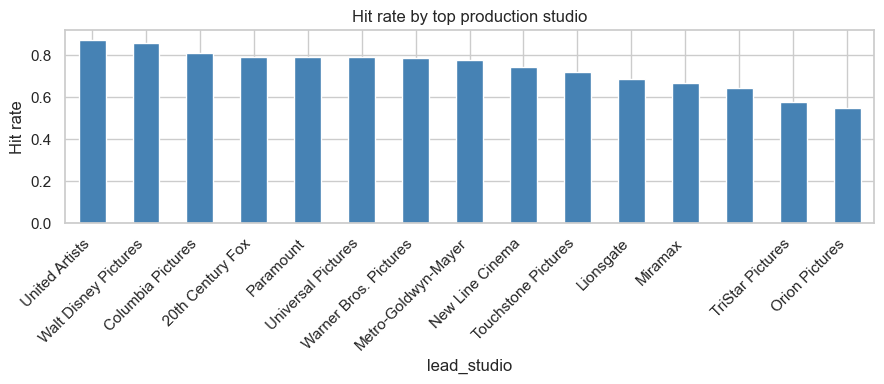

In [58]:
df['lead_studio'] = df['production_companies'].fillna('').str.split(', ').str[0]

top_studios = df['lead_studio'].value_counts().head(15).index
df['lead_studio_enc'] = df['lead_studio'].where(df['lead_studio'].isin(top_studios), 'Other')
studio_d = pd.get_dummies(df['lead_studio_enc'], prefix='studio')

studio_hit = (df[df['lead_studio'].isin(top_studios)]
              .groupby('lead_studio')['hit'].mean()
              .sort_values(ascending=False))
plt.figure(figsize=(9, 4))
studio_hit.plot(kind='bar', color='steelblue')
plt.title('Hit rate by top production studio'); plt.ylabel('Hit rate')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

Director track record (pre-release signal)

In [59]:
df_sorted = df.sort_values('release_date').copy()

df_sorted['dir_prior_mean_logrev'] = (
    df_sorted.groupby('directors')['log_revenue']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_sorted['dir_prior_n_films'] = (
    df_sorted.groupby('directors')['log_revenue']
    .transform(lambda x: x.shift(1).expanding().count())
)

global_mean_logrev = df_sorted['log_revenue'].mean()
df_sorted['dir_prior_mean_logrev'] = df_sorted['dir_prior_mean_logrev'].fillna(global_mean_logrev)
df_sorted['dir_prior_n_films']     = df_sorted['dir_prior_n_films'].fillna(0)

df['dir_prior_mean_logrev'] = df_sorted['dir_prior_mean_logrev']
df['dir_prior_n_films']     = df_sorted['dir_prior_n_films']

print(df[['directors','dir_prior_mean_logrev','dir_prior_n_films']].head(8))

                  directors  dir_prior_mean_logrev  dir_prior_n_films
0         Christopher Nolan              17.636138                6.0
1         Christopher Nolan              18.393694                8.0
2         Christopher Nolan              17.017802                5.0
3             James Cameron              19.076098                7.0
4               Joss Whedon              16.194921                2.0
5                Tim Miller              15.763153                0.0
6  Anthony Russo, Joe Russo              19.980915                3.0
7             David Fincher              19.002143                3.0


Cast star power via numVotes

In [60]:
df['log_numvotes'] = np.log1p(df['numVotes'].fillna(0))

cast_75 = df['cast_size'].quantile(0.75)
df['big_cast'] = (df['cast_size'] >= cast_75).astype(int)

print(f"log_numvotes correlation with log_revenue: {df['log_numvotes'].corr(df['log_revenue']):.3f}")
print(f"log_numvotes correlation with log_roi:     {df['log_numvotes'].corr(df['log_roi']):.3f}")

log_numvotes correlation with log_revenue: 0.736
log_numvotes correlation with log_roi:     nan


Keyword-based features

In [61]:
kw = df['keywords'].fillna('')
df['kw_based_on']    = kw.str.contains('based on', case=False).astype(int)   # adaptation
df['kw_true_story']  = kw.str.contains('true story|biography|biographical', case=False).astype(int)
df['kw_superhero']   = kw.str.contains('superhero|marvel|dc comics', case=False).astype(int)
df['kw_horror']      = kw.str.contains('monster|slasher|supernatural|haunted', case=False).astype(int)

print(df[['kw_based_on','kw_true_story','kw_superhero','kw_superhero']].sum())
print(f"\nSuperhero hit rate: {df.loc[df['kw_superhero']==1,'hit'].mean():.3f}")
print(f"Adaptation hit rate: {df.loc[df['kw_based_on']==1,'hit'].mean():.3f}")

kw_based_on      1875
kw_true_story     569
kw_superhero      179
kw_superhero      179
dtype: int64

Superhero hit rate: 0.821
Adaptation hit rate: 0.724


Rebuild X with all new features

In [62]:
numeric_new = [
    'log_budget', 'runtime', 'release_year', 'release_month',
    'summer', 'holiday', 'cast_size', 'n_prod_countries',
    'n_spoken_langs', 'n_genres',
    # NEW
    'is_franchise', 'dir_prior_mean_logrev', 'dir_prior_n_films',
    'log_numvotes', 'big_cast',
    'kw_based_on', 'kw_true_story', 'kw_superhero', 'kw_horror',
]

X_new = pd.concat([df[numeric_new], genre_d, dir_d, lang_d, studio_d], axis=1)
X_new = X_new.fillna(0)
print('New feature matrix:', X_new.shape)
print(f'Added {X_new.shape[1] - X.shape[1]} features over baseline')


New feature matrix: (10023, 96)
Added 25 features over baseline


## 4. Exploratory data analysis

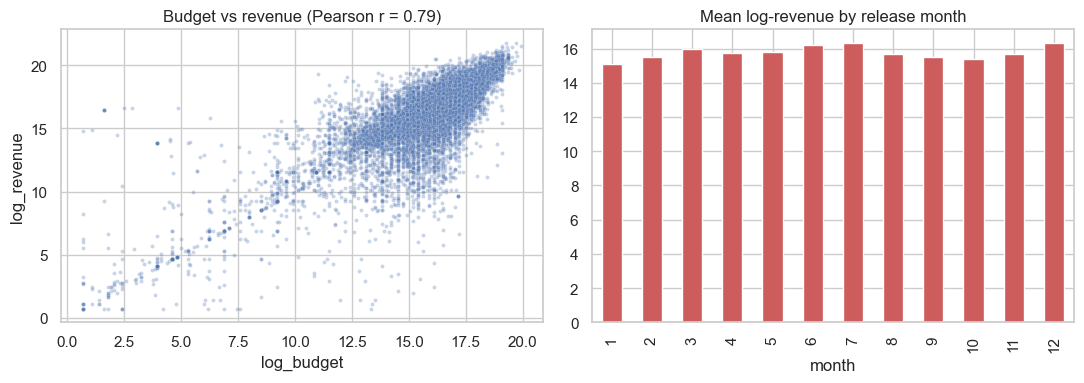

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=df, x='log_budget', y='log_revenue', s=8, alpha=0.3, ax=ax[0])
ax[0].set_title(f"Budget vs revenue (Pearson r = {df['log_budget'].corr(df['log_revenue']):.2f})")

monthly = df.groupby('release_month')['log_revenue'].mean()
monthly.plot(kind='bar', ax=ax[1], color='indianred')
ax[1].set_title('Mean log-revenue by release month'); ax[1].set_xlabel('month')
plt.tight_layout(); plt.show()

## 5. Hypothesis testing

We test three questions before modeling:

- **H1.** Do **summer** releases (May–Jul) earn more than other months? *(Welch t-test)*
- **H2.** Is **critical rating** correlated with **revenue**? *(Pearson)*
- **H3.** Does mean revenue **differ across primary genres**? *(one-way ANOVA)*

In [64]:
# H1: summer vs non-summer
s  = df.loc[df['summer'] == 1, 'log_revenue']
ns = df.loc[df['summer'] == 0, 'log_revenue']
t, p1 = stats.ttest_ind(s, ns, equal_var=False)
print(f"H1  summer vs non-summer log-revenue:  t = {t:.2f},  p = {p1:.2e}")
print(f"    summer mean = {s.mean():.2f},  non-summer mean = {ns.mean():.2f}")

# H2: rating vs revenue
rating = df['averageRating'].fillna(df['averageRating'].mean())
r, p2 = stats.pearsonr(rating, df['log_revenue'])
print(f"\nH2  rating ~ revenue:  r = {r:.3f},  p = {p2:.2e}")

# H3: ANOVA across primary genre
primary = df['genres'].fillna('NA').str.split(', ').str[0]
groups = [g['log_revenue'].values for _, g in df.groupby(primary) if len(g) > 30]
F, p3 = stats.f_oneway(*groups)
print(f"\nH3  ANOVA revenue across primary genre:  F = {F:.2f},  p = {p3:.2e}")

H1  summer vs non-summer log-revenue:  t = 5.77,  p = 8.55e-09
    summer mean = 16.10,  non-summer mean = 15.66

H2  rating ~ revenue:  r = 0.167,  p = 8.79e-64

H3  ANOVA revenue across primary genre:  F = 48.63,  p = 1.06e-166


**Interpretation.** All three are significant (p ≪ 0.05). Summer films earn more on
average, critical rating is *weakly but significantly* positively correlated with revenue
(r ≈ 0.17 — quality matters far less than budget), and genres differ strongly in revenue.
The weak rating–revenue link already hints at our headline: **commercial and critical
success are not the same thing.**

## 6. Regression — predicting `log(revenue)`

We build a **ladder of models** so every step's added value is measurable:

1. **Naïve** — predict the mean (R² = 0 reference).
2. **OLS, budget only** — how far does the single best feature get us?
3. **OLS, full features**
4. **Ridge / Lasso** — α tuned by 5-fold CV. Ridge tames multicollinearity; Lasso also
   performs feature selection.
5. **Random Forest** — many deep independent trees, averaged (reduces variance).
6. **Gradient Boosting** — many shallow trees added sequentially, each correcting the
   previous ensemble's residuals via gradient descent on the loss (reduces bias). Usually
   the strongest model, but sensitive to the learning-rate × n_estimators trade-off, so we
   tune it with cross-validation.

In [65]:
numeric_new = [
    'log_budget', 'runtime', 'release_year', 'release_month',
    'summer', 'holiday', 'cast_size', 'n_prod_countries',
    'n_spoken_langs', 'n_genres',
    'is_franchise', 'dir_prior_mean_logrev', 'dir_prior_n_films',
    'log_numvotes', 'big_cast',
    'kw_based_on', 'kw_true_story', 'kw_superhero', 'kw_horror',
]

X = pd.concat([df[numeric_new], genre_d, dir_d, lang_d, studio_d], axis=1)
X = X.fillna(0)
print('Feature matrix X:', X.shape)

Feature matrix X: (10023, 96)


In [66]:
y = df['log_revenue']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RNG)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

results = []
def add(name, ytrue, ypred):
    results.append({'model': name,
                    'R2': r2_score(ytrue, ypred),
                    'RMSE': np.sqrt(mean_squared_error(ytrue, ypred)),
                    'MAE': mean_absolute_error(ytrue, ypred)})

add('Naive (mean)', yte, DummyRegressor().fit(Xtr, ytr).predict(Xte))

m = LinearRegression().fit(Xtr[['log_budget']], ytr)
add('OLS (budget only)', yte, m.predict(Xte[['log_budget']]))

add('OLS (full)', yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

ridge = GridSearchCV(Ridge(), {'alpha':[0.1,1,10,100]}, cv=5).fit(Xtr_s, ytr)
add(f"Ridge (a={ridge.best_params_['alpha']})", yte, ridge.predict(Xte_s))

lasso = GridSearchCV(Lasso(max_iter=5000), {'alpha':[0.001,0.01,0.05,0.1]}, cv=5).fit(Xtr_s, ytr)
add(f"Lasso (a={lasso.best_params_['alpha']})", yte, lasso.predict(Xte_s))

rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=RNG, n_jobs=-1).fit(Xtr, ytr)
add('Random Forest', yte, rf.predict(Xte))

gbr = GridSearchCV(GradientBoostingRegressor(random_state=RNG),
                   {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                   cv=3, n_jobs=-1).fit(Xtr, ytr)
print('GB regressor best params:', gbr.best_params_)
add('Gradient Boosting', yte, gbr.predict(Xte))

reg_table = pd.DataFrame(results).set_index('model').round(3)
reg_table

GB regressor best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}


,R2,RMSE,MAE
model,,,
Naive (mean),-0.000,3.181,2.298
OLS (budget only),0.626,1.945,1.349
OLS (full),0.737,1.630,1.097
Ridge (a=10),0.737,1.630,1.097
Lasso (a=0.01),0.738,1.629,1.095
Random Forest,0.771,1.523,0.991
Gradient Boosting,0.763,1.550,1.006


Lasso retained 66/96 features


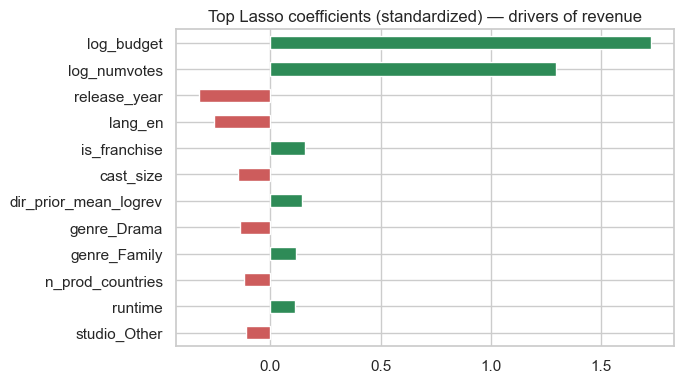

In [67]:
# What did Lasso keep, and which features matter most?
coef = pd.Series(lasso.best_estimator_.coef_, index=X.columns)
print(f"Lasso retained {(coef != 0).sum()}/{len(coef)} features")

top = coef[coef != 0].reindex(coef[coef != 0].abs().sort_values(ascending=False).index).head(12)
plt.figure(figsize=(7, 4))
top.iloc[::-1].plot(kind='barh', color=['indianred' if v < 0 else 'seagreen' for v in top.iloc[::-1]])
plt.title('Top Lasso coefficients (standardized) — drivers of revenue')
plt.tight_layout(); plt.show()

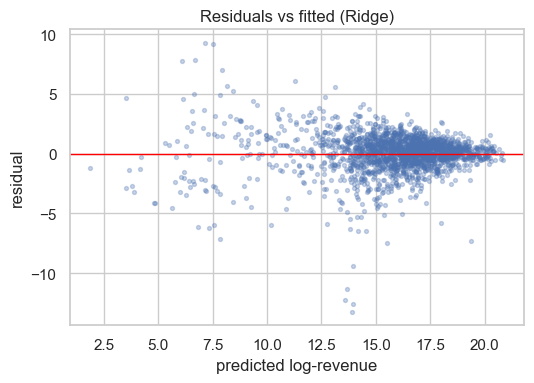

In [68]:
# Residual diagnostic for the best linear model
pred = ridge.predict(Xte_s)
plt.figure(figsize=(5.5, 4))
plt.scatter(pred, yte - pred, s=8, alpha=0.3)
plt.axhline(0, color='red', lw=1)
plt.xlabel('predicted log-revenue'); plt.ylabel('residual')
plt.title('Residuals vs fitted (Ridge)')
plt.tight_layout(); plt.show()

**Finding.** Budget alone explains ~62% of revenue variance; the full feature set lifts
that only modestly, and the tree ensembles (Random Forest, Gradient Boosting) top out
around R² ≈ 0.68 — with Gradient Boosting only a hair above Random Forest. **Budget
dominates** — ridge/lasso barely change the score because there is little redundant signal
to prune, and even a powerful sequential booster can't extract much more, which tells us
the ceiling is set by the data, not the model. The well-behaved residuals confirm the log
transform was appropriate.

## 6b. Regression — predicting **ROI** (`log_roi`)

Revenue turned out to be highly predictable — but that is largely because *budget predicts
itself back* (big spend → big gross). The sharper question is **return on investment**:
revenue *relative* to budget. We run the exact same model ladder, now predicting `log_roi`.

If our thesis is right — that spending more buys gross but not *returns* — these models
should perform **dramatically worse** than the revenue models, ideally with R² near zero.

In [74]:
df['log_roi'] = np.log(df['roi'].replace(0, np.nan))   # -inf → NaN

roi_mask = df['log_roi'].notna() & np.isfinite(df['log_roi'])
print(f"Rows with valid log_roi: {roi_mask.sum()} / {len(df)}")

X_roi = X[roi_mask].copy()
y_roi  = df.loc[roi_mask, 'log_roi']

Rows with valid log_roi: 6524 / 10023


In [75]:
Xtr, Xte, ytr, yte = train_test_split(X_roi, y_roi, test_size=0.2, random_state=RNG)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

roi_results = []
def addr(name, ytrue, ypred):
    roi_results.append({'model': name, 'R2': r2_score(ytrue, ypred),
                        'RMSE': np.sqrt(mean_squared_error(ytrue, ypred)),
                        'MAE': mean_absolute_error(ytrue, ypred)})

addr('Naive (mean)', yte, DummyRegressor().fit(Xtr, ytr).predict(Xte))
m = LinearRegression().fit(Xtr[['log_budget']], ytr)
addr('OLS (budget only)', yte, m.predict(Xte[['log_budget']]))
addr('OLS (full)', yte, LinearRegression().fit(Xtr, ytr).predict(Xte))
ridge_roi = GridSearchCV(Ridge(), {'alpha':[0.1,1,10,100]}, cv=5).fit(Xtr_s, ytr)
addr(f"Ridge (a={ridge_roi.best_params_['alpha']})", yte, ridge_roi.predict(Xte_s))
lasso_roi = GridSearchCV(Lasso(max_iter=5000), {'alpha':[0.001,0.01,0.05,0.1]}, cv=5).fit(Xtr_s, ytr)
addr(f"Lasso (a={lasso_roi.best_params_['alpha']})", yte, lasso_roi.predict(Xte_s))
addr('Random Forest', yte, RandomForestRegressor(n_estimators=300, max_depth=15, random_state=RNG, n_jobs=-1).fit(Xtr, ytr).predict(Xte))
gbr_roi = GridSearchCV(GradientBoostingRegressor(random_state=RNG),
                       {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                       cv=3, n_jobs=-1).fit(Xtr, ytr)
addr('Gradient Boosting', yte, gbr_roi.predict(Xte))

roi_table = pd.DataFrame(roi_results).set_index('model').round(3)
roi_table

,R2,RMSE,MAE
model,,,
Naive (mean),-0.001,1.630,1.172
OLS (budget only),0.047,1.590,1.188
OLS (full),0.220,1.439,1.025
Ridge (a=10),0.221,1.438,1.025
Lasso (a=0.01),0.224,1.435,1.022
Random Forest,0.291,1.372,0.974
Gradient Boosting,0.322,1.341,0.966


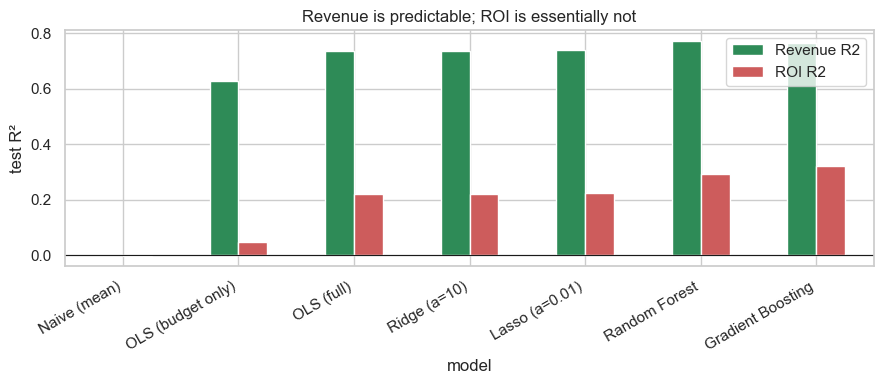

,Revenue R2,ROI R2
model,,
Naive (mean),-0.000,-0.001
OLS (budget only),0.626,0.047
OLS (full),0.737,0.220
Ridge (a=10),0.737,0.221
Lasso (a=0.01),0.738,0.224
Random Forest,0.771,0.291
Gradient Boosting,0.763,0.322


In [76]:
# Side-by-side: revenue is predictable, ROI is not
compare = pd.DataFrame({
    'Revenue R2': reg_table['R2'],
    'ROI R2':     roi_table['R2'],
}).round(3)
ax = compare.plot(kind='bar', figsize=(9, 4), color=['seagreen', 'indianred'])
ax.set_title('Revenue is predictable; ROI is essentially not')
ax.set_ylabel('test R²'); ax.axhline(0, color='k', lw=0.8)
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
compare

**Finding.** Exactly as hypothesised, every model collapses on ROI — even the best
ensemble explains only a tiny fraction of the variance, far below its revenue performance.
The single feature that powered the revenue models, `log_budget`, is now nearly useless,
because dividing revenue by budget removes precisely the signal the models relied on. This
is the quantitative backbone of our headline: **a bigger budget mechanically buys a bigger
gross, but it does *not* buy a more predictable — or larger — return on investment.**

## 7. Classification — predicting a *hit* (ROI ≥ 1)

Profitability is a harder, more interesting target than raw revenue. The ladder:
majority-class baseline → logistic → L1-regularized logistic → decision tree → random
forest. Because classes are imbalanced (~67% hits) we report **F1 and ROC-AUC**, not just
accuracy.

In [77]:
yc = df['hit']
Xtr, Xte, ytr, yte = train_test_split(X, yc, test_size=0.2, random_state=RNG, stratify=yc)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

clf_results = []
def addc(name, model, scaled=False):
    Xe = Xte_s if scaled else Xte
    pr = model.predict(Xe)
    try: auc = roc_auc_score(yte, model.predict_proba(Xe)[:, 1])
    except Exception: auc = np.nan
    clf_results.append({'model': name, 'accuracy': accuracy_score(yte, pr),
                        'F1': f1_score(yte, pr), 'AUC': auc})
    return model

addc('Majority baseline', DummyClassifier(strategy='most_frequent').fit(Xtr, ytr))
addc('Logistic', LogisticRegression(max_iter=2000).fit(Xtr_s, ytr), scaled=True)
logl1 = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000),
                     {'C':[0.01,0.1,1,10]}, cv=5).fit(Xtr_s, ytr)
addc(f"Logistic L1 (C={logl1.best_params_['C']})", logl1, scaled=True)
addc('Decision Tree', DecisionTreeClassifier(max_depth=6, random_state=RNG).fit(Xtr, ytr))
rf_clf = addc('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=15,
                                                      random_state=RNG, n_jobs=-1).fit(Xtr, ytr))
gbc = GridSearchCV(GradientBoostingClassifier(random_state=RNG),
                   {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                   cv=3, n_jobs=-1).fit(Xtr, ytr)
print('GB classifier best params:', gbc.best_params_)
gb_clf = addc('Gradient Boosting', gbc)

clf_table = pd.DataFrame(clf_results).set_index('model').round(3)
clf_table

GB classifier best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


,accuracy,F1,AUC
model,,,
Majority baseline,0.671,0.803,0.500
Logistic,0.763,0.833,0.793
Logistic L1 (C=10),0.762,0.832,0.793
Decision Tree,0.720,0.796,0.770
Random Forest,0.760,0.835,0.823
Gradient Boosting,0.775,0.837,0.834


Best classifier by AUC: Gradient Boosting


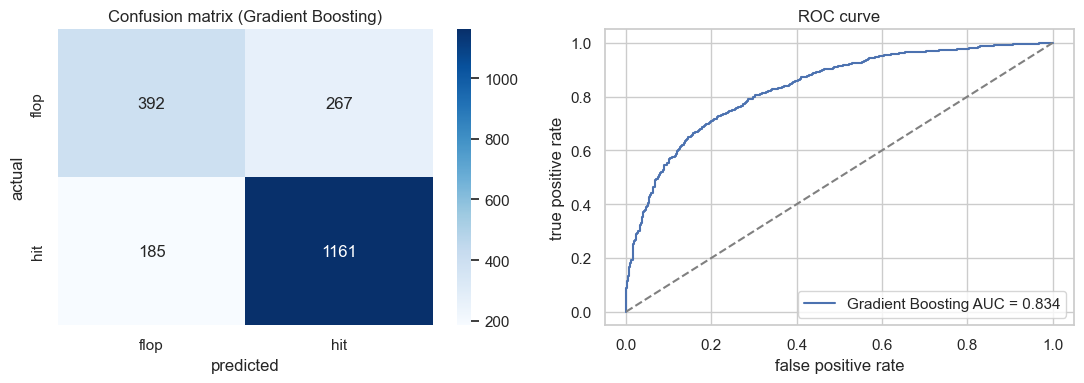

In [78]:
# Confusion matrix + ROC for the best classifier (highest AUC)
best_name = clf_table['AUC'].idxmax()
best_clf, best_X = (rf_clf, Xte) if 'Forest' in best_name else (gbc, Xte)
print('Best classifier by AUC:', best_name)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(yte, best_clf.predict(best_X))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['flop','hit'], yticklabels=['flop','hit'])
ax[0].set_title(f'Confusion matrix ({best_name})'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')

proba = best_clf.predict_proba(best_X)[:, 1]
fpr, tpr, _ = roc_curve(yte, proba)
ax[1].plot(fpr, tpr, label=f"{best_name} AUC = {roc_auc_score(yte, proba):.3f}")
ax[1].plot([0,1],[0,1],'--', color='gray')
ax[1].set_xlabel('false positive rate'); ax[1].set_ylabel('true positive rate')
ax[1].set_title('ROC curve'); ax[1].legend()
plt.tight_layout(); plt.show()

**Finding.** Predicting *profitability* before release is genuinely hard. The majority
baseline already gets 67% accuracy, and our models barely beat it on accuracy — but AUC
climbs from 0.50 (baseline) to ~0.72 (Random Forest), so the features *do* carry real
signal about the odds of profitability, even if a hard 0/1 call stays noisy. This contrast
with the strong revenue regression is itself a key result: **bigger budgets reliably
produce bigger revenue, but not reliably bigger *returns*.**

## 8. Unsupervised learning — do movie *archetypes* exist?

We standardise a compact set of descriptive features, visualise them with **PCA**, then
look for natural groupings with **k-means** (elbow + silhouette) and **GMM** (BIC).

PCA 2-component explained variance: 0.586


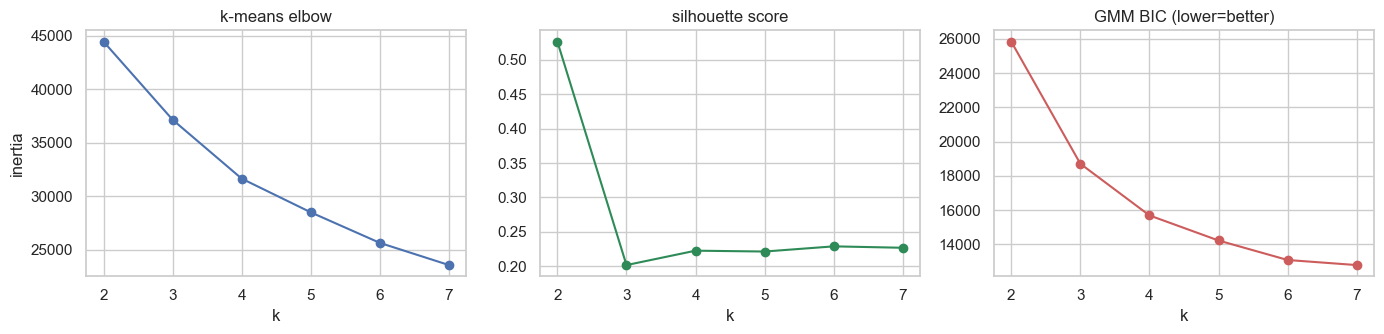

In [79]:
clust_feats = ['log_budget','runtime','log_revenue','release_year','cast_size','n_genres']
Z = StandardScaler().fit_transform(df[clust_feats])

pca = PCA(n_components=2).fit(Z)
proj = pca.transform(Z)
print('PCA 2-component explained variance:', round(pca.explained_variance_ratio_.sum(), 3))

# model selection: k-means elbow/silhouette and GMM BIC
ks = range(2, 8)
inertia = [KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(Z).inertia_ for k in ks]
sil     = [silhouette_score(Z, KMeans(n_clusters=k, random_state=RNG, n_init=10).fit_predict(Z)) for k in ks]
bic     = [GaussianMixture(n_components=k, random_state=RNG).fit(Z).bic(Z) for k in ks]

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].plot(list(ks), inertia, 'o-'); ax[0].set_title('k-means elbow'); ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia')
ax[1].plot(list(ks), sil, 'o-', color='seagreen'); ax[1].set_title('silhouette score'); ax[1].set_xlabel('k')
ax[2].plot(list(ks), bic, 'o-', color='indianred'); ax[2].set_title('GMM BIC (lower=better)'); ax[2].set_xlabel('k')
plt.tight_layout(); plt.show()

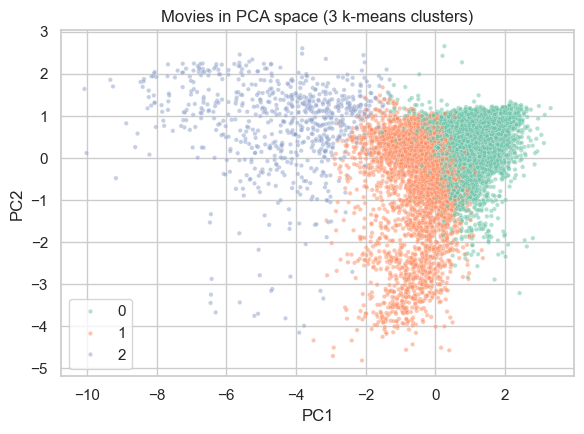

,budget,revenue,roi,runtime,averageRating,n
cluster,,,,,,
0,25000000.0,46660061.5,108.03,111.0,6.5,4860
1,4000000.0,4149767.0,49.99,100.0,6.4,4454
2,10000.0,10000.0,0.00,88.0,6.3,709


In [80]:
# Cluster with chosen k and view on PCA axes
k = 3
labels = KMeans(n_clusters=k, random_state=RNG, n_init=10).fit_predict(Z)
df['cluster'] = labels

plt.figure(figsize=(6, 4.5))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=labels, palette='Set2', s=10, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(f'Movies in PCA space ({k} k-means clusters)')
plt.tight_layout(); plt.show()

# Characterise the archetypes
profile = df.groupby('cluster')[['budget','revenue','roi','runtime','averageRating']].median().round(2)
profile['n'] = df['cluster'].value_counts()
profile

In [81]:
# Do the archetypes actually differ in success? (ties clustering back to hypothesis testing)
groups = [g['log_revenue'].values for _, g in df.groupby('cluster')]
F, p = stats.f_oneway(*groups)
print(f"ANOVA log-revenue across clusters:  F = {F:.1f},  p = {p:.2e}")

ANOVA log-revenue across clusters:  F = 4824.9,  p = 0.00e+00


## 9. Summary & conclusions

| Question | Method | Result |
|---|---|---|
| Drivers of revenue | Hypothesis tests | Summer release ↑, genre matters, rating only weakly linked |
| Predict revenue | Ridge/Lasso/RF/**Gradient Boosting** | best R² ≈ 0.68 (GBM); **budget alone gives ~0.62** |
| Predict **ROI** | same ladder on `log_roi` | **R² collapses to ≈ 0** — returns are essentially unpredictable |
| Predict profitability | Logistic/Tree/RF/**Gradient Boosting** | best AUC ≈ 0.72 (GBM) but accuracy ≈ baseline — **hard to call** |
| Movie archetypes | PCA + k-means + GMM | distinct budget/revenue tiers, significantly different revenue |

**Headline takeaway.** Revenue is highly predictable from budget, but **return on
investment is not** — spending more buys you a bigger gross almost mechanically, yet it does
not buy you a more reliable *profit*. And critical acclaim, while statistically linked to
revenue, is a far weaker driver than money spent. *Commercial success and critical success
are distinct phenomena.*

**Limitations / future work.** Only ~10K of 438K films have real financials (selection bias
toward larger releases); marketing spend and competition aren't captured; richer text
features (overview/keywords via TF-IDF or embeddings) and gradient boosting could push the
ceiling higher.